In [1]:
#!which python
#!python3 -m pip install addict

In [2]:
from pathlib import Path
import torch
import cv2
from groundingdino.util.inference import load_model, load_image, predict, annotate

ROOT = Path("/workspace/third_party/GroundingDINO") #Path.cwd()

CONFIG_PATH = ROOT / "groundingdino/config/GroundingDINO_SwinT_OGC.py"

CHECKPOINT_CANDIDATES = [
    ROOT / "weights/groundingdino_swint_ogc.pth",
    ROOT / "../weights/groundingdino_swint_ogc.pth",
    ROOT / "../../checkpoints/groundingdino_swint_ogc.pth",
]
checkpoint_path = next((p for p in CHECKPOINT_CANDIDATES if p.exists()), None)
if checkpoint_path is None:
    raise FileNotFoundError(f"checkpoint not found: {CHECKPOINT_CANDIDATES}")

IMAGE_CANDIDATES = [
    ROOT / ".asset/cat_dog.jpeg",
    ROOT / "demo/test.jpg",
]
image_path = next((p for p in IMAGE_CANDIDATES if p.exists()), None)
if image_path is None:
    raise FileNotFoundError(f"image not found: {IMAGE_CANDIDATES}")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device={device}")
print(f"checkpoint={checkpoint_path}")
print(f"image={image_path}")

model = load_model(str(CONFIG_PATH), str(checkpoint_path), device=device)

TEXT_PROMPT = "chair . person . dog . cat"
BOX_TRESHOLD = 0.35
TEXT_TRESHOLD = 0.25

image_source, image = load_image(str(image_path))

boxes, logits, phrases = predict(
    model=model,
    image=image,
    caption=TEXT_PROMPT,
    box_threshold=BOX_TRESHOLD,
    text_threshold=TEXT_TRESHOLD,
    device=device,
)

annotated_frame = annotate(image_source=image_source, boxes=boxes, logits=logits, phrases=phrases)
out_path = ROOT / "annotated_image.jpg"
cv2.imwrite(str(out_path), annotated_frame)
print(f"saved={out_path}")
print(f"detections={len(phrases)}")
print(phrases)

device=cuda
checkpoint=/workspace/third_party/GroundingDINO/weights/groundingdino_swint_ogc.pth
image=/workspace/third_party/GroundingDINO/.asset/cat_dog.jpeg
final text_encoder_type: bert-base-uncased


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 17444.13it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


saved=/workspace/third_party/GroundingDINO/annotated_image.jpg
detections=2
['cat', 'dog']


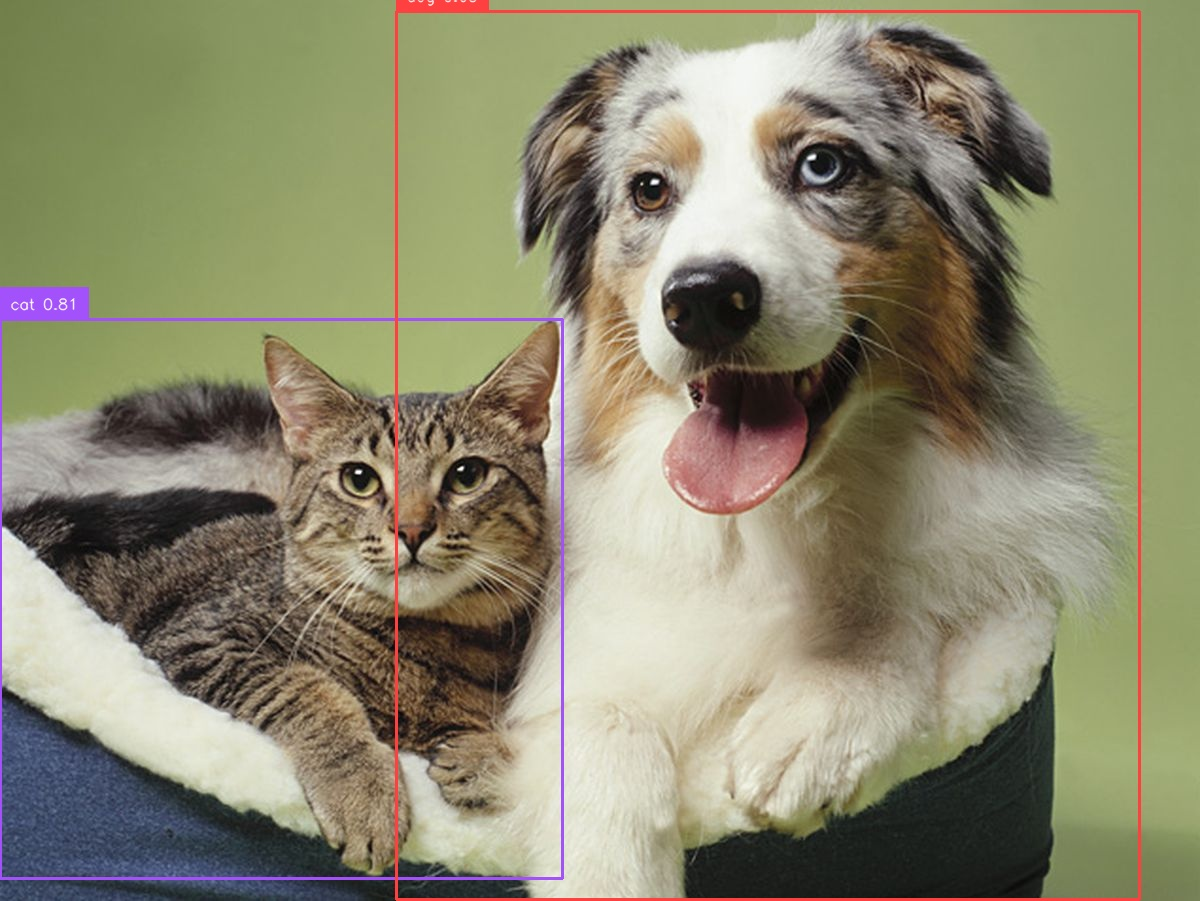

In [3]:
# 出力画層をここに表示
from IPython.display import Image, display
display(Image(filename=str(out_path)))

In [4]:
import os

base = "/workspace/third_party/segment-anything"
print(os.listdir(base))

['CONTRIBUTING.md', 'segment_anything', 'demo', 'scripts', 'segment_anything.egg-info', '.flake8', 'assets', 'notebooks', 'LICENSE', 'setup.cfg', 'CODE_OF_CONDUCT.md', 'README.md', 'setup.py', 'linter.sh']


In [5]:
from pathlib import Path
import torch
import cv2
import numpy as np

# GroundingDINO
from groundingdino.util.inference import load_model, load_image, predict, annotate

# SAM
import sys
sys.path.append("/workspace/third_party/segment-anything")
from segment_anything import sam_model_registry, SamPredictor

ROOT = Path("/workspace/third_party/GroundingDINO") #Path.cwd()

# ==============================
# GroundingDINO設定
# ==============================
CONFIG_PATH = ROOT / "groundingdino/config/GroundingDINO_SwinT_OGC.py"

CHECKPOINT_CANDIDATES = [
    ROOT / "weights/groundingdino_swint_ogc.pth",
    ROOT / "../weights/groundingdino_swint_ogc.pth",
    ROOT / "../../checkpoints/groundingdino_swint_ogc.pth",
]
checkpoint_path = next((p for p in CHECKPOINT_CANDIDATES if p.exists()), None)
if checkpoint_path is None:
    raise FileNotFoundError(f"checkpoint not found: {CHECKPOINT_CANDIDATES}")

IMAGE_CANDIDATES = [
    ROOT / ".asset/cat_dog.jpeg",
    ROOT / "demo/test.jpg",
]
image_path = next((p for p in IMAGE_CANDIDATES if p.exists()), None)
if image_path is None:
    raise FileNotFoundError(f"image not found: {IMAGE_CANDIDATES}")

# ==============================
# SAM設定
# ==============================
# SAM_CHECKPOINT = ROOT / "weights/sam_vit_h_4b8939.pth"
SAM_CHECKPOINT = Path("/workspace/weights/sam_vit_h_4b8939.pth")
SAM_TYPE = "vit_h"

device = "cuda" if torch.cuda.is_available() else "cpu"

# ==============================
# モデルロード
# ==============================
dino_model = load_model(str(CONFIG_PATH), str(checkpoint_path), device=device)

sam = sam_model_registry[SAM_TYPE](checkpoint=str(SAM_CHECKPOINT))
sam.to(device=device)
predictor = SamPredictor(sam)

# ==============================
# 推論
# ==============================
TEXT_PROMPT = "dog . cat ."
BOX_TRESHOLD = 0.4
TEXT_TRESHOLD = 0.35

image_source, image = load_image(str(image_path))

boxes, logits, phrases = predict(
    model=dino_model,
    image=image,
    caption=TEXT_PROMPT,
    box_threshold=BOX_TRESHOLD,
    text_threshold=TEXT_TRESHOLD,
    device=device,
)

# ==============================
# SAM用にBBox変換
# ==============================
h, w, _ = image_source.shape


def box_cxcywh_to_xyxy(boxes):
    cx, cy, bw, bh = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    x1 = cx - bw / 2
    y1 = cy - bh / 2
    x2 = cx + bw / 2
    y2 = cy + bh / 2
    return torch.stack([x1, y1, x2, y2], dim=1)

# GroundingDINOは[0,1]正規化 → pixelへ
#boxes_xyxy = boxes * torch.tensor([w, h, w, h])
#boxes_xyxy = boxes_xyxy.cpu().numpy()
boxes_xyxy = box_cxcywh_to_xyxy(boxes)
boxes_xyxy = boxes_xyxy * torch.tensor([w, h, w, h])
boxes_xyxy = boxes_xyxy.cpu().numpy()
# ==============================
# SAM推論
# ==============================
predictor.set_image(image_source)

masks = []
for box in boxes_xyxy:
    mask, score, _ = predictor.predict(
        box=box,
        multimask_output=False
    )
    masks.append(mask[0])

from copy import deepcopy
masks_original = deepcopy(masks)

final text_encoder_type: bert-base-uncased


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 16536.24it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
# ==============================
# 可視化（マスク重ねる）
# ==============================
overlay = image_source.copy()
colors = [
    np.array([0, 255, 0]),   # dog
    np.array([255, 0, 0]),   # cat
]
for i, mask in enumerate(masks):
    color = colors[i % len(colors)]
    overlay[mask] = overlay[mask] * 0.5 + color * 0.5

# ==============================
# 保存
# ==============================
out_path = "./sam_masked.jpg"
cv2.imwrite(str(out_path), overlay)

print(f"saved={out_path}")
print(f"detections={len(phrases)}")
print(phrases)

saved=./sam_masked.jpg
detections=2
['cat', 'dog']


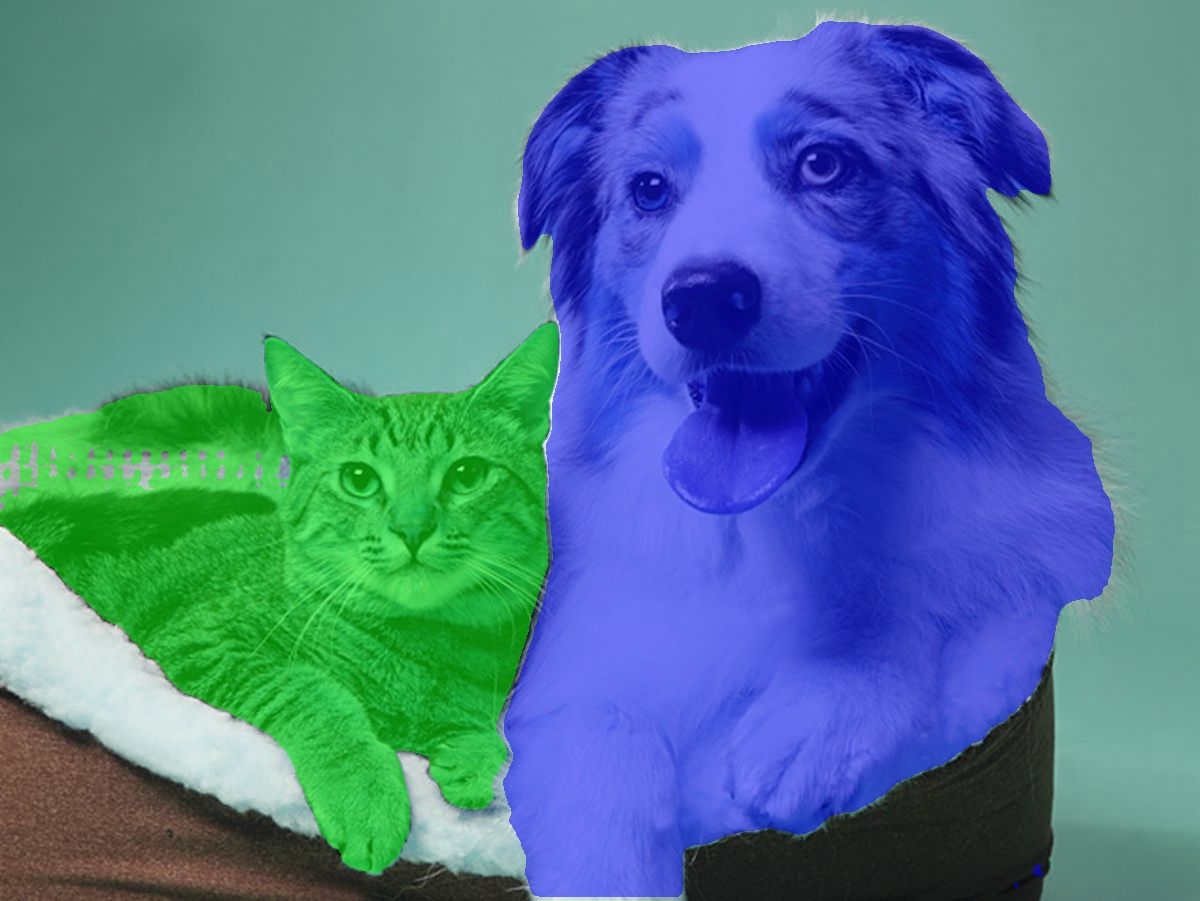

In [7]:
# out_path をここに表示
from IPython.display import Image, display 
display(Image(filename=str(out_path)))

In [8]:
masks_original[0].dtype

dtype('bool')

In [9]:
import cv2
import numpy as np

def post_process_mask(mask, flags=[True, True, True, True]):
    # 0/1 の uint8 に統一
    mask = (mask > 0).astype(np.uint8)
    print("step-input mask.sum =", mask.sum())

    kernel = np.ones((5, 5), np.uint8)

    if flags[0]:
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        mask = (mask > 0).astype(np.uint8)
        print("step-1 mask.sum =", mask.sum())

    if flags[1]:
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        mask = (mask > 0).astype(np.uint8)
        print("step-2 mask.sum =", mask.sum())

    if flags[2]:
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
        print("step-3 num_labels =", num_labels)

        # 背景しかない場合
        if num_labels <= 1:
            print("step-3 mask.sum =", mask.sum())
            print("step-last mask.sum =", mask.sum())
            return mask

        if flags[3]:
            areas = stats[1:, cv2.CC_STAT_AREA]
            if len(areas) == 0:
                print("step-3 mask.sum =", mask.sum())
                print("step-last mask.sum =", mask.sum())
                return mask

            largest = 1 + np.argmax(areas)
            mask = (labels == largest).astype(np.uint8)

        print("step-3 mask.sum =", mask.sum())

    print("step-last mask.sum =", mask.sum())
    print(mask.dtype, mask.min(), mask.max())
    return mask

In [10]:
# マスクの後処理
masks2 = deepcopy(masks_original)
#flags = [True, True, False, False]
flags = [False, False, True, True]
for i in range(len(masks2)):
    masks2[i] = post_process_mask(masks2[i], flags)

step-input mask.sum = 174582
step-3 num_labels = 3
step-3 mask.sum = 174520
step-last mask.sum = 174520
uint8 0 1
step-input mask.sum = 398454
step-3 num_labels = 4
step-3 mask.sum = 398342
step-last mask.sum = 398342
uint8 0 1


In [11]:
# ==============================
# 可視化（マスク重ねる）
# ==============================
overlay = image_source.copy()
colors = [
    np.array([0, 255, 0]),   # dog
    np.array([255, 0, 0]),   # cat
]
for i, mask in enumerate(masks2):
    color = colors[i % len(colors)]
    overlay[mask.astype(bool)] = overlay[mask.astype(bool)] * 0.5 + color * 0.5

# ==============================
# 保存
# ==============================
out_path = "./sam_masked_2.jpg"
cv2.imwrite(str(out_path), overlay)

print(f"saved={out_path}")
print(f"detections={len(phrases)}")
print(phrases)

saved=./sam_masked_2.jpg
detections=2
['cat', 'dog']


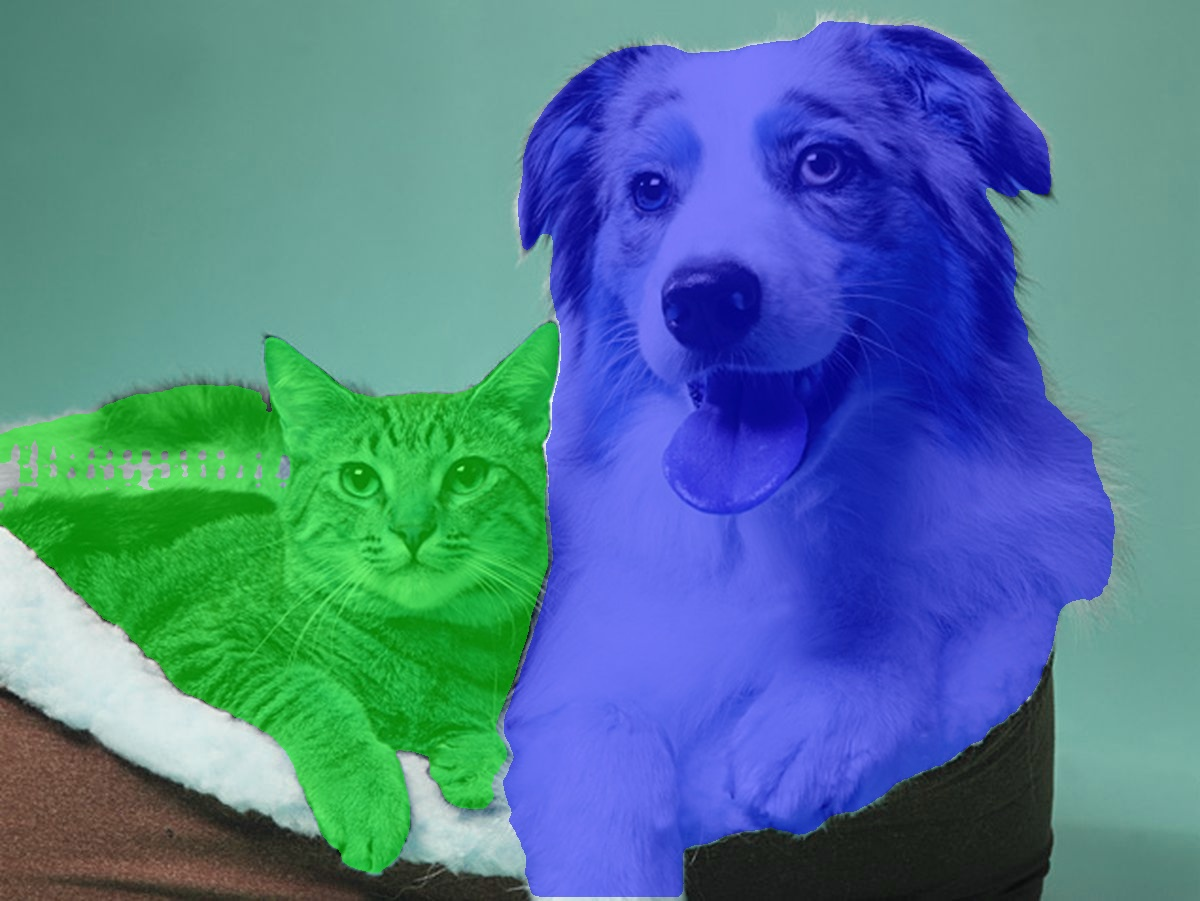

In [12]:
# out_path をここに表示
from IPython.display import Image, display 
display(Image(filename=str(out_path)))